In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV

In [3]:

df = pd.read_csv('/content/sample_data/adult_income.csv')

display(df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Question 1: Exploratory Data Analysis (EDA) -20

Problem Statement:

Find the three most important factors that separate individuals who earn more than $50K annually from those who earn $50K or less.
Tasks:

Perform EDA using appropriate charts and basic descriptive statistics.
Select your top 3 features and justify your choices using visual and statistical evidence.

For each selected feature, explain in simple terms why it intuitively affects income.

Rank your 3 features from most important to least important, provide why you think that ?


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
?,2809
Transport-moving,2355


In [6]:
df.shape

(48842, 15)

In [7]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


<Axes: xlabel='hours-per-week', ylabel='Count'>

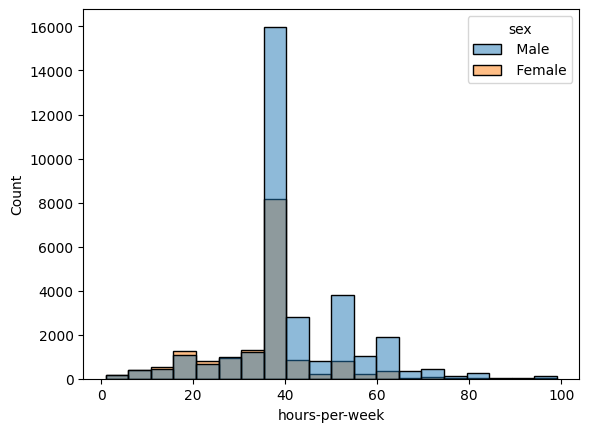

In [9]:
sns.histplot(data = df , x='hours-per-week' , hue = 'sex'  ,bins =20)

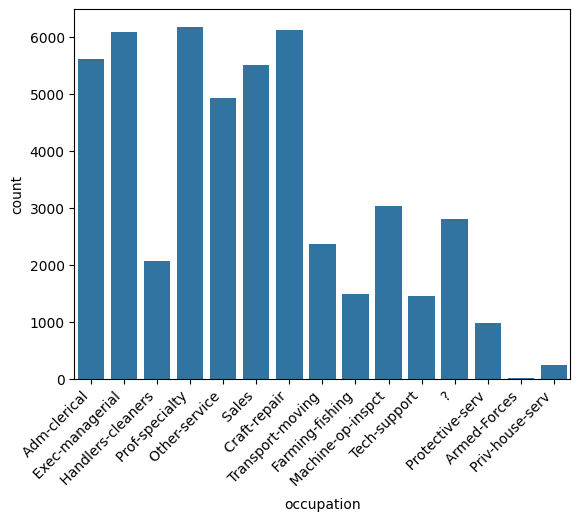

In [10]:
sns.countplot(data = df , x='occupation')
plt.xticks(rotation=45, ha='right')
plt.show()

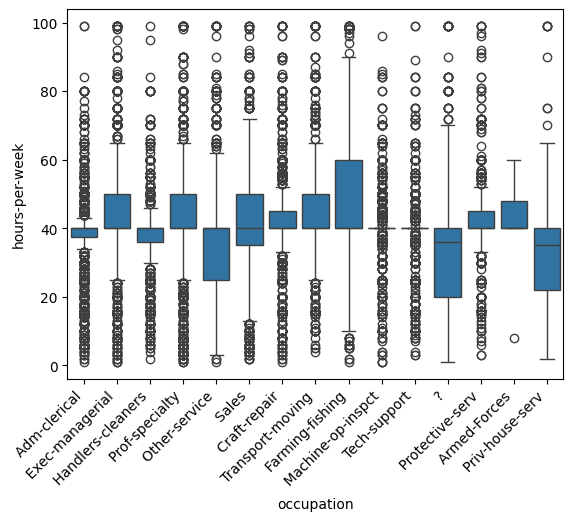

In [11]:
sns.boxplot(data = df , x='occupation' , y='hours-per-week')
plt.xticks(rotation=45, ha='right')
plt.show()

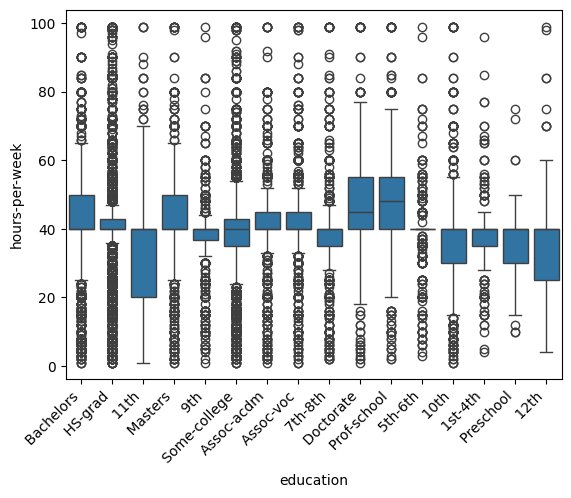

In [12]:
sns.boxplot(data = df , x='education' , y='hours-per-week')
plt.xticks(rotation=45, ha='right')
plt.show()

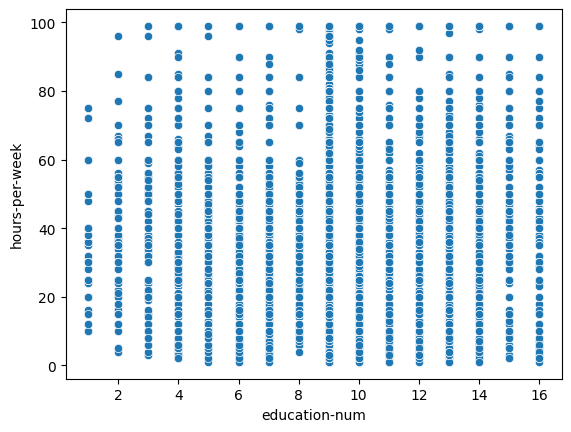

In [13]:
sns.scatterplot(data = df , x='education-num' , y='hours-per-week')

plt.show()

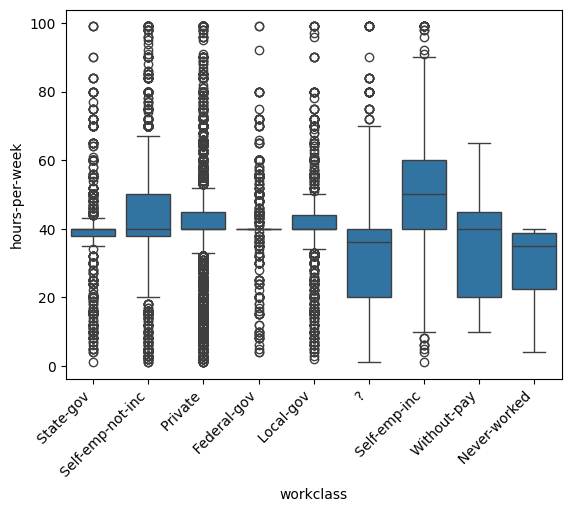

In [14]:
sns.boxplot(data  =df , x='workclass' , y='hours-per-week')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='sex', ylabel='hours-per-week'>

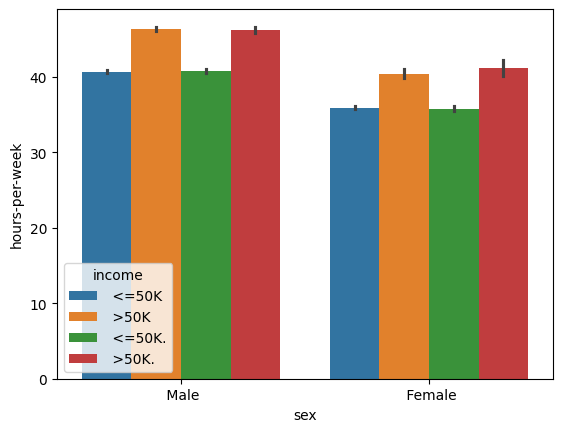

In [15]:
sns.barplot(data= df , x= 'sex' , y= 'hours-per-week' , hue='income')


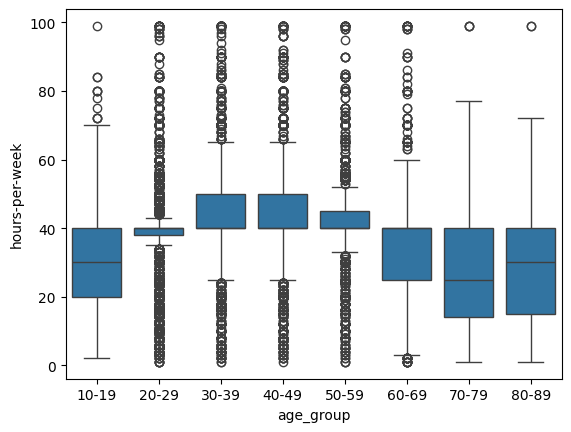

In [16]:
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ['10-19', '20-29', '30-39', '40-49',
          '50-59', '60-69', '70-79', '80-89']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

sns.boxplot(data=df, x='age_group', y='hours-per-week')

plt.show()

### **Top 3 features** and justification  using visual and statistical evidence.

### **Education** : bcz with more education peaple earn more hours per week  ( ref : box plot)

### **Occupation**:  some certain occupations have trendency of providing hiher hours per salary (ref : box plot)

### **Age**  : bcz younger peolple (25-45) earns more compared to minor(<25 ) and older ( >50) ( ref : boxplot)



### **Ranking 3 featuure**

### **1. Education** : Higher education leads to  higher-paying professional jobs.no other feature creates this much sifference

### **2. Occupation**  : Effects Salary like Executives and professionals  earns above 50 K

### **3. Age** : 25-45 is the most active years so they are more likely to to exceed 50 K

###


**Question 2: Preprocessing Pipeline**

**Design (Regression) - 20**

**Problem Statement:**

Predicting a continuous variable requires clean, properly formatted data. You will design a preprocessing pipeline to prepare the dataset for predicting hours-per-week based on the other available features.

Tasks:

Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.

Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.


<Axes: xlabel='age', ylabel='Density'>

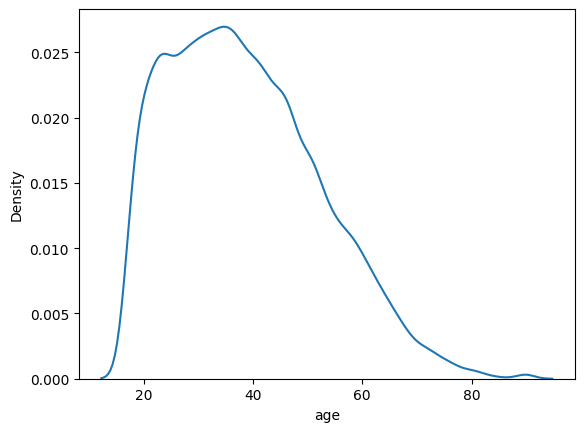

In [17]:
sns.kdeplot(data = df , x= 'age')

<Axes: xlabel='education-num', ylabel='Density'>

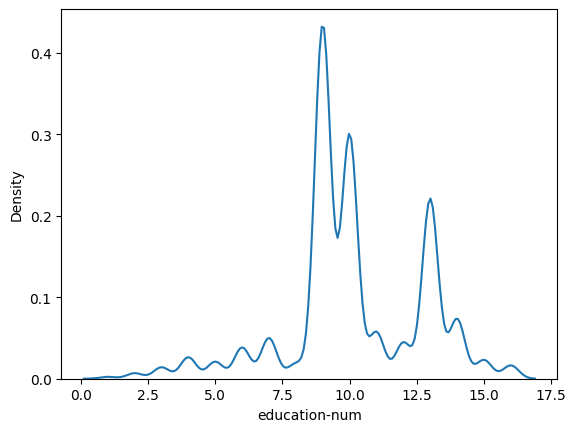

In [18]:
sns.kdeplot(data = df , x= 'education-num')

<Axes: xlabel='capital-gain', ylabel='Density'>

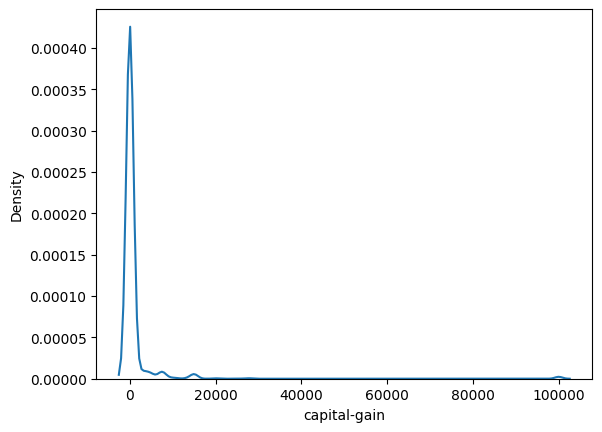

In [19]:
sns.kdeplot(data = df , x= 'capital-gain')

<Axes: xlabel='capital-loss', ylabel='Density'>

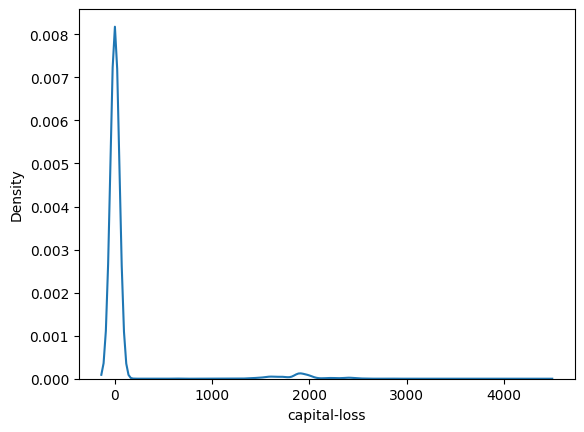

In [20]:
sns.kdeplot(data = df , x= 'capital-loss')

In [21]:
df.drop(['education' , 'fnlwgt' , 'age_group'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education-num   48842 non-null  int64 
 3   marital-status  48842 non-null  object
 4   occupation      48842 non-null  object
 5   relationship    48842 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital-gain    48842 non-null  int64 
 9   capital-loss    48842 non-null  int64 
 10  hours-per-week  48842 non-null  int64 
 11  native-country  48842 non-null  object
 12  income          48842 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.8+ MB


In [22]:
X= df.drop('hours-per-week' , axis = 1)
y= df['hours-per-week']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)




(39073, 12)

(9769, 12)

(39073,)

(9769,)

In [23]:
display(X_train.head(3))
display(y_train.head(3))



,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,income
37193,32,Private,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,United-States,<=50K.
31093,45,State-gov,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,United-States,>50K
33814,35,Local-gov,8,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,United-States,<=50K.


,hours-per-week
37193,40
31093,40
33814,40


In [24]:
categorical_features = ['workclass' , 'marital-status' , 'occupation' , 'relationship' , 'race' , 'sex' , 'native-country' , 'income']
numerical_features = ['age' , 'education-num' , 'capital-gain' , 'capital-loss' ]

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numerical_transformer = Pipeline ( steps =[
    ('imputer' , SimpleImputer(strategy = 'mean')) ,
    ('scler' , StandardScaler())   # capital-gain , capital-loss are different scale
])

categorical_transformer= Pipeline( steps =[
    ('imputer' , SimpleImputer(strategy = 'most_frequent')) ,
    ('encoder' , OneHotEncoder(sparse_output = False , drop = 'first' , handle_unknown = 'ignore'))

])
numerical_transformer
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [26]:

preprocessor= ColumnTransformer(transformers=[
    ('numerical_pipeline' ,numerical_transformer , numerical_features ),
    ('categorical_pipeline' , categorical_transformer , categorical_features)
] ,
      remainder='passthrough'
                                )

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical_pipeline',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss']),
                                ('categorical_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native-country', 'income'])])

## Documentation :
### Miising values -> so  using **imputer**

### Capital-gain , capital-loss are different scale ->** StandardScaler **

### workclass ,marital-status,occupation ,relationshi ,race ,sex,native-country ,income are **Nominal category**  -> so Use OneHotEncoder

###  'education' is **Ordinaal Category**
### but 'education' category is converted to 'educaion-num' , so we dont need 'education' , just dropping it

### **Question 3:** Regression Modeling &
Evaluation - 20

Problem Statement:

Utilizing the preprocessing pipeline designed in Question 2, train two different regression models to predict hours-per-week and evaluate their performance.

Tasks:

Train a standard Linear Regression model using your pipeline.

Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.

Evaluate and compare both models using R2, MAE, and MSE.

Briefly discuss which model performed better and why.


In [27]:
# Linear Regression
linear_pipeline = Pipeline( steps=[
    ('preprocessor' , preprocessor) ,
    ('model' , LinearRegression())
])

linear_pipeline.fit(X_train,y_train)


#SGD Regression

SGD_pipeline= Pipeline ( steps =[
    ('preprocessor' ,preprocessor),
    ('model' , SGDRegressor())
])

SGD_pipeline.fit(X_train , y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'income'])])),
                ('model', SGDRegressor())])

In [28]:
y_pred_linear = linear_pipeline.predict(X_test)

y_pred_SGD = SGD_pipeline.predict(X_test)

print(y_pred_linear[:5])
print(y_pred_SGD[:5])

[39.08037882 32.27864995 37.80989182 32.66818874 41.14384052]
[39.58691374 32.6178118  37.77333238 32.93797478 39.48372271]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Accuracy

In [29]:
print(" for Linear Regression:")
print(f"MSE: {round(mean_squared_error(y_test, y_pred_linear), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred_linear), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred_linear), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred_linear), 4)}")

print("\n for SGD Regression:")
print(f"MSE: {round(mean_squared_error(y_test, y_pred_SGD), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred_SGD), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred_SGD), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred_SGD), 4)}")

 for Linear Regression:
MSE: 123.2498
R2: 0.1961
RMSE: 11.1018
MAE: 7.6836

 for SGD Regression:
MSE: 123.4459
R2: 0.1948
RMSE: 11.1106
MAE: 7.6749


### SGD vs Linear Regression :
Both models produced nearly same results  SGD Regression is just an optimization method for solving the same linear regression problem — it finds the same solution via gradient descent rather than the closed-form equation. The tiny differences (MSE 123.25 vs 123.44) are just numerical approximation differences, not meaningful model differences.


## **Question -4 : Problem Statement:**

Shift your focus from regression back to classification. Build an end-to-end Logistic Regression pipeline to predict whether a person earns more than $50K annually ( income feature)

**Tasks:**

Construct a new Scikit-Learn Pipeline that includes your new preprocessing steps and a Logistic Regression classifier.

Train the model and evaluate its performance on a test set using Accuracy, Precision, and Recall.



In [30]:
df2= df = pd.read_csv('/content/sample_data/adult_income.csv')

display(df2.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [31]:
df2.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


,count
income,
<=50K,24720
<=50K.,12435
>50K,7841
>50K.,3846


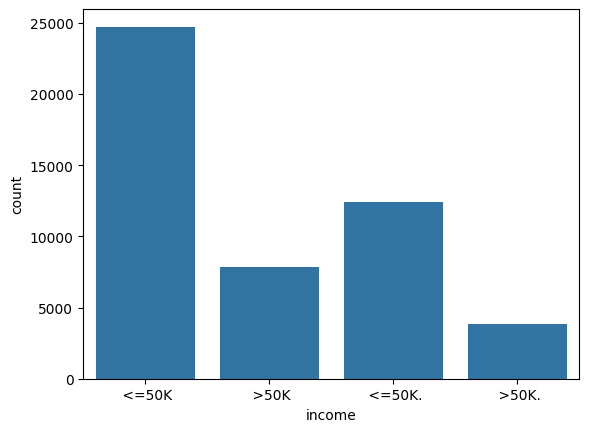

In [32]:
sns.countplot(data =df2 , x='income')
df2['income'].value_counts()

In [33]:
df2['income'] = df2['income'].str.strip()

df2['income']= df2['income'].map({
    '<=50K': 0,
    '<=50K.': 0,
    '>50K': 1,
    '>50K.': 1
})

df2['income'].value_counts()

,count
income,
0,37155
1,11687


## 'income' :
## <=50K  → 0
##  >50K   → 1

In [34]:
df2.drop(['education' , 'fnlwgt'], axis=1, inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education-num   48842 non-null  int64 
 3   marital-status  48842 non-null  object
 4   occupation      48842 non-null  object
 5   relationship    48842 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital-gain    48842 non-null  int64 
 9   capital-loss    48842 non-null  int64 
 10  hours-per-week  48842 non-null  int64 
 11  native-country  48842 non-null  object
 12  income          48842 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 4.8+ MB


In [35]:
X2=df2.drop('income', axis = 1)
y2=df2['income']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify =y2)

# stratify splits train-test on same same ratio og target , (0/1 same ratio)
display(X_train2.shape)
display(X_test2.shape)
display(y_train2.shape)
display(y_test2.shape)

display(X_train2)
display(X_test2)
display(y_train2)
display(y_test2)



(39073, 12)

(9769, 12)

(39073,)

(9769,)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
34495,37,Private,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States
18591,56,Self-emp-inc,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States
12562,53,Private,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States
552,72,Private,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
3479,46,State-gov,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
37700,45,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States
16092,58,State-gov,13,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,20,United-States
26498,61,Federal-gov,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,1887,40,United-States
20647,38,Private,11,Never-married,Tech-support,Not-in-family,White,Female,0,0,40,United-States


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
40421,30,Private,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States
47738,54,State-gov,12,Divorced,Adm-clerical,Not-in-family,White,Male,0,0,39,United-States
518,21,?,10,Never-married,?,Unmarried,White,Female,0,0,35,United-States
8564,35,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,2885,0,40,United-States
31355,42,Local-gov,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
20403,37,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States
28091,34,Self-emp-not-inc,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States
22164,59,Private,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,30,United-States
24820,29,Private,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,40,United-States


,income
34495,0
18591,0
12562,0
552,0
3479,0
...,...
37700,1
16092,1
26498,1
20647,0


,income
40421,0
47738,0
518,0
8564,0
31355,1
...,...
20403,0
28091,0
22164,1
24820,0


In [36]:
numerical__transformer2 =Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='mean')),
    ('scaler' , StandardScaler())

])


catgorical_transformer2 = Pipeline(steps =[
    ('imputer' , SimpleImputer(strategy = 'most_frequent')) ,
    ('encoder' , OneHotEncoder(sparse_output = False , drop = 'first' , handle_unknown = 'ignore'))
])

catgorical_transformer2

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [37]:
categorical_features2 = ['workclass' , 'marital-status' , 'occupation' , 'relationship' , 'race' , 'sex' , 'native-country' ]
numerical_features2 = ['age' , 'education-num' , 'capital-gain' , 'capital-loss' , 'hours-per-week']

In [38]:
processor2 = ColumnTransformer(transformers=[
    ('numerical_pipeline' ,numerical__transformer2 , numerical_features2 ),
    ('categorical_pipeline' , catgorical_transformer2 , categorical_features2)
] ,
      remainder='passthrough'
                                )
processor2

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical_pipeline',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week']),
                                ('categorical_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native-country'])])

In [39]:
logistic_model = Pipeline( steps =[
    ('preprocessor' , processor2),
    ('model' , LogisticRegression())
])

logistic_model.fit(X_train2 , y_train2)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('model', LogisticRegression())])

In [40]:
logistic_model['model'].coef_
logistic_model['model'].intercept_
logistic_model['model'].classes_

array([0, 1])

In [41]:
y_pred2= logistic_model.predict(X_test2)

print(y_pred2)


[0 0 0 ... 0 0 0]


In [42]:
logistic_model.predict_proba(X_test2)

array([[0.99281823, 0.00718177],
       [0.88453965, 0.11546035],
       [0.99519847, 0.00480153],
       ...,
       [0.55449413, 0.44550587],
       [0.97265579, 0.02734421],
       [0.69348264, 0.30651736]])

In [43]:
accuracy = accuracy_score(y_test2 , y_pred2)
print('Accuracy:', accuracy) # like 75 % accuracy
precision = precision_score(y_test2 , y_pred2)
print('Precision:', precision)
recall = recall_score(y_test2 , y_pred2)
print('Recall:', recall)

Accuracy: 0.8509571092230526
Precision: 0.7284974093264248
Recall: 0.6013686911890505


 ## **Question 5: Hyperparameter Tuning & Model Comparison**

Problem Statement:

Train KNN model to classify income column. Determine if a distance based model like K-Nearest Neighbors (KNN) can outperform your Logistic Regression model when properly optimized.
Tasks:

Use GridSearchCV to systematically tune a KNN Classifier on hyperparameters: n_neighbors, weights, and metric.
Once the optimal KNN model is found, evaluate it using Accuracy, Precision, and Recall.

Comparison: Compare the performance metrics of your Tuned KNN model against the default Logistic Regression model. Which algorithm performed better overall.


In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education-num   48842 non-null  int64 
 3   marital-status  48842 non-null  object
 4   occupation      48842 non-null  object
 5   relationship    48842 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital-gain    48842 non-null  int64 
 9   capital-loss    48842 non-null  int64 
 10  hours-per-week  48842 non-null  int64 
 11  native-country  48842 non-null  object
 12  income          48842 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 4.8+ MB


In [45]:
display(X_train2.shape)
display(X_test2.shape)
display(y_train2.shape)
display(y_test2.shape)

(39073, 12)

(9769, 12)

(39073,)

(9769,)

In [46]:
knn_model = Pipeline(steps =[
    ('preprocessor' , processor2) ,
    ('model' , KNeighborsClassifier())
])


knn_model.fit(X_train2, y_train2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('model', KNeighborsClassifier())])

In [47]:
print(y_train2.dtype)
print(y_train2.unique())

int64
[0 1]


In [48]:
# convert dtype for cuML compatibility
y_train2 = y_train2.astype('int32')
y_test2  = y_test2.astype('int32')

# verify
print(y_train2.dtype)   # should print int32
print(y_train2.unique() if hasattr(y_train2, 'unique') else y_train2[:5])

int32
[0 1]


### GridSearchCV

In [50]:
import cupy as cp
from cuml.neighbors import KNeighborsClassifier
from cuml.model_selection import GridSearchCV as cuGridSearchCV

# Step 1 — preprocess
preprocessor = knn_model.named_steps['preprocessor']
X_train_processed = preprocessor.fit_transform(X_train2)
X_test_processed  = preprocessor.transform(X_test2)

# Step 2 — convert to GPU
X_train_gpu = cp.array(X_train_processed)
X_test_gpu  = cp.array(X_test_processed)
y_train_gpu = cp.array(y_train2)
y_test_gpu  = cp.array(y_test2)

# Step 3 — model and grid
knn_gpu = KNeighborsClassifier()

grid = {
    'n_neighbors': list(range(1, 100, 5)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

# Step 4 — grid search
grid_search = cuGridSearchCV(
    estimator=knn_gpu,
    param_grid=grid,
    cv=3
)

# Explicitly convert y_train_gpu to a NumPy array for fitting to avoid TypeError
grid_search.fit(X_train_gpu, y_train_gpu.get())

# Step 5 — results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:  ", grid_search.best_score_)

[I] [11:26:39.241860] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:39.248918] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.277759] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.368785] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.457797] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.552023] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.604180] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.655411] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.710398] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.768043] Unused keyword parameter: n_jobs during cuML estimator initialization
[I] [11:26:46.821106] Unused keyword parameter: n_jobs during cuML estimator ini

In [51]:
best_knn = KNeighborsClassifier(
    n_neighbors=46,
    weights='uniform',
    metric='euclidean'
)

best_knn.fit(X_train_gpu, y_train_gpu)
y_pred_gpu = best_knn.predict(X_test_gpu)

import numpy as np
from sklearn.metrics import accuracy_score, classification_report

y_pred    = cp.asnumpy(y_pred_gpu)
y_test_np = cp.asnumpy(y_test_gpu)

print("Test Accuracy:", accuracy_score(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred,
      target_names=['<=50K', '>50K']))

Test Accuracy: 0.8556658818712253
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.61      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769

